In [ ]:
# Install R in Colab
!apt-get install -y r-base

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
r-base is already the newest version (4.5.2-1.2204.0).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [ ]:
!R -e "install.packages(c('caret','pROC'), repos='http://cran.us.r-project.org')"


R version 4.5.2 (2025-10-31) -- "[Not] Part in a Rumble"
Copyright (C) 2025 The R Foundation for Statistical Computing
Platform: x86_64-pc-linux-gnu

R is free software and comes with ABSOLUTELY NO WARRANTY.
You are welcome to redistribute it under certain conditions.
Type 'license()' or 'licence()' for distribution details.

  Natural language support but running in an English locale

R is a collaborative project with many contributors.
Type 'contributors()' for more information and
'citation()' on how to cite R or R packages in publications.

Type 'demo()' for some demos, 'help()' for on-line help, or
'help.start()' for an HTML browser interface to help.
Type 'q()' to quit R.

> install.packages(c('caret','pROC'), repos='http://cran.us.r-project.org')
Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependencies ‘clock’, ‘recipes’

trying URL 'http://cran.us.r-project.org/src/contrib/clock_0.7.4.tar.gz'
trying URL 'http://cran.us

Loading required package: ggplot2

Loading required package: lattice

Type 'citation("pROC")' for a citation.


Attaching package: ‘pROC’


The following objects are masked from ‘package:stats’:

    cov, smooth, var




'data.frame':	1000 obs. of  62 variables:
 $ Duration                              : int  6 48 12 42 24 36 24 36 12 30 ...
 $ Amount                                : int  1169 5951 2096 7882 4870 9055 2835 6948 3059 5234 ...
 $ InstallmentRatePercentage             : int  4 2 2 2 3 2 3 2 2 4 ...
 $ ResidenceDuration                     : int  4 2 3 4 4 4 4 2 4 2 ...
 $ Age                                   : int  67 22 49 45 53 35 53 35 61 28 ...
 $ NumberExistingCredits                 : int  2 1 1 1 2 1 1 1 1 2 ...
 $ NumberPeopleMaintenance               : int  1 1 2 2 2 2 1 1 1 1 ...
 $ Telephone                             : num  0 1 1 1 1 0 1 0 1 1 ...
 $ ForeignWorker                         : num  1 1 1 1 1 1 1 1 1 1 ...
 $ Class                                 : Factor w/ 2 levels "Bad","Good": 2 1 2 2 1 2 2 2 2 1 ...
 $ CheckingAccountStatus.lt.0            : num  1 0 0 1 1 0 0 0 0 0 ...
 $ CheckingAccountStatus.0.to.200        : num  0 1 0 0 0 0 0 1 0 1 ...
 $ CheckingAccoun


Call:
glm(formula = Class ~ Duration + Amount + Age + InstallmentRatePercentage, 
    family = binomial, data = train)

Coefficients:
                            Estimate Std. Error z value Pr(>|z|)    
(Intercept)               -1.759e+00  3.772e-01  -4.662 3.13e-06 ***
Duration                   2.478e-02  8.432e-03   2.939  0.00329 ** 
Amount                     6.041e-05  3.738e-05   1.616  0.10606    
Age                       -1.430e-02  7.439e-03  -1.922  0.05464 .  
InstallmentRatePercentage  2.030e-01  8.027e-02   2.529  0.01143 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 959.84  on 799  degrees of freedom
Residual deviance: 919.32  on 795  degrees of freedom
AIC: 929.32

Number of Fisher Scoring iterations: 4


(Intercept)                  Duration                    Amount 
                0.1722760                 1.0250935                 1.0000604 
                      Age InstallmentRatePercentage 
                0.9858062                 1.2251062

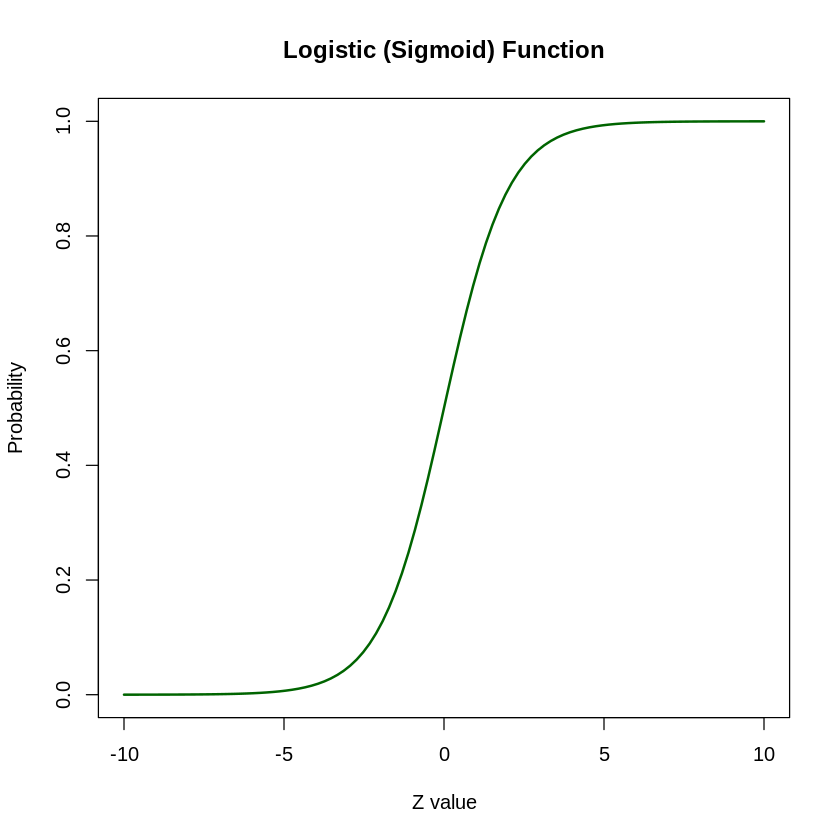

Confusion Matrix and Statistics

          Reference
Prediction   0   1
         0 129  65
         1   1   5
                                          
               Accuracy : 0.67            
                 95% CI : (0.6002, 0.7347)
    No Information Rate : 0.65            
    P-Value [Acc > NIR] : 0.3039          
                                          
                  Kappa : 0.0808          
                                          
 Mcnemar's Test P-Value : 8.851e-15       
                                          
            Sensitivity : 0.99231         
            Specificity : 0.07143         
         Pos Pred Value : 0.66495         
         Neg Pred Value : 0.83333         
             Prevalence : 0.65000         
         Detection Rate : 0.64500         
   Detection Prevalence : 0.97000         
      Balanced Accuracy : 0.53187         
                                          
       'Positive' Class : 0               
                              

Setting levels: control = 0, case = 1

Setting direction: controls < cases



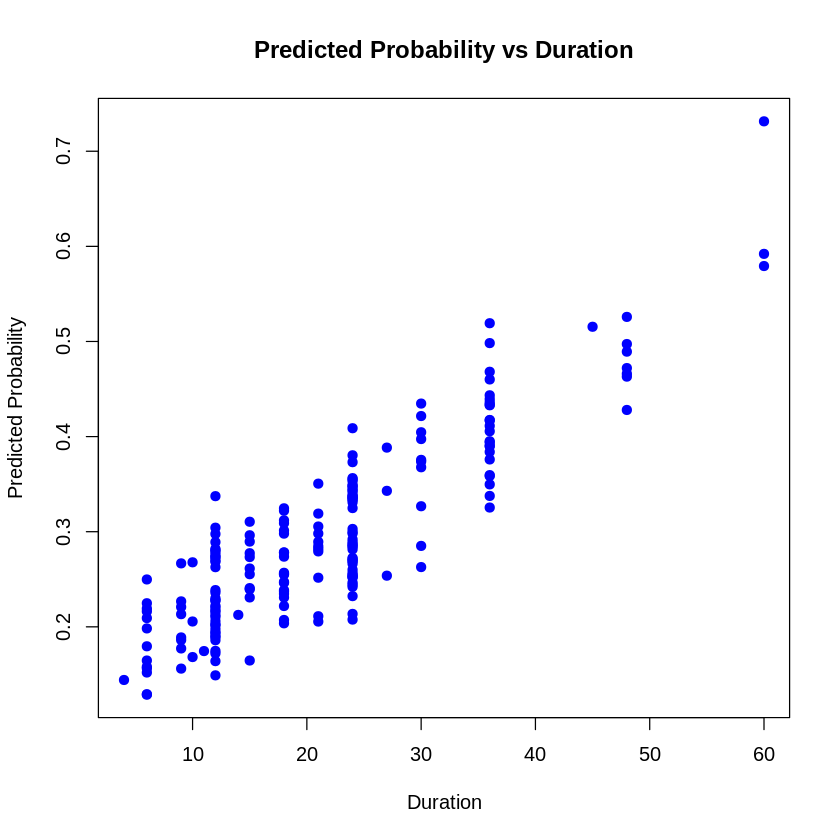

Area under the curve: 0.6741

[1] 0.04221391

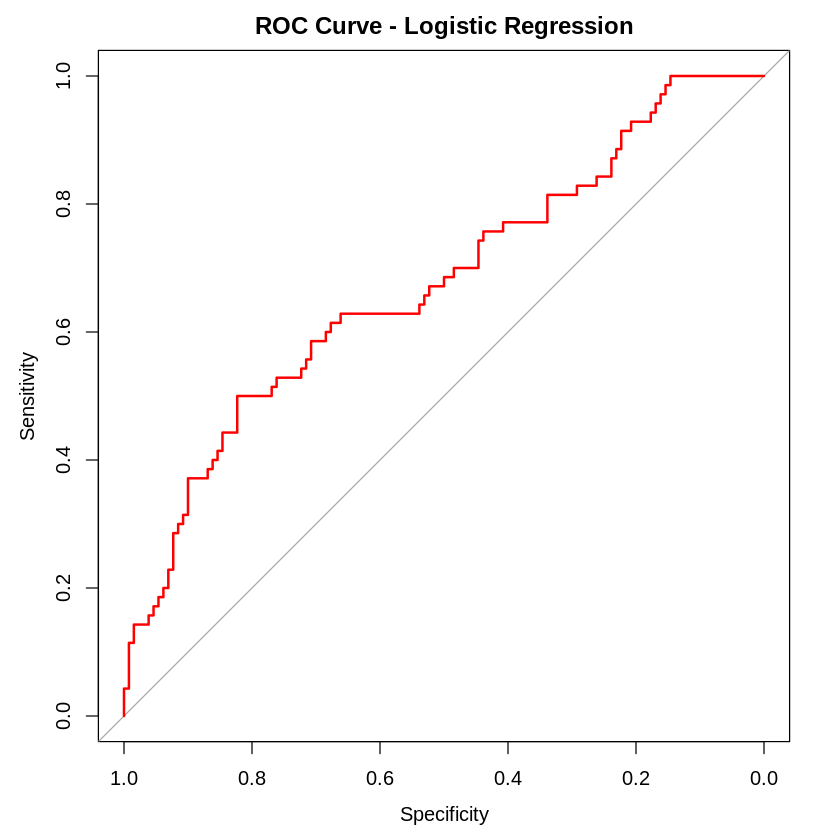

In [ ]:


# Logistic Regression - Customer Churn


# Load Libraries


library(caret)
library(pROC)

# Load Dataset


data(GermanCredit)

# View structure
str(GermanCredit)

# Dependent and Independent Variables


# Dependent Variable (Y):
# Class -> Customer churn
# Convert "Bad" to 1 (Churn)
# Convert "Good" to 0 (No Churn)

GermanCredit$Class <- ifelse(GermanCredit$Class == "Bad", 1, 0)

# Independent Variables (X):
# Duration, Amount, Age, InstallmentRatePercentage

# Train-Test Split (80% Train, 20% Test)


set.seed(123)

sample_index <- sample(1:nrow(GermanCredit),
                       0.8 * nrow(GermanCredit))

train <- GermanCredit[sample_index, ]
test  <- GermanCredit[-sample_index, ]

# Logistic Regression Model


model <- glm(Class ~ Duration + Amount + Age +
               InstallmentRatePercentage,
             data = train,
             family = binomial)

summary(model)


# Logistic (Sigmoid) Curve Graph

z <- seq(-10, 10, length=100)
sigmoid <- 1 / (1 + exp(-z))

plot(z, sigmoid,
     type="l",
     col="darkgreen",
     lwd=2,
     main="Logistic (Sigmoid) Function",
     xlab="Z value",
     ylab="Probability")

# Odds Ratio


exp(coef(model))

# Prediction


pred_prob <- predict(model, test, type = "response")
pred_class <- ifelse(pred_prob > 0.5, 1, 0)

# Probability vs Duration Graph


plot(test$Duration, pred_prob,
     col="blue",
     pch=19,
     main="Predicted Probability vs Duration",
     xlab="Duration",
     ylab="Predicted Probability")

# Confusion Matrix


confusionMatrix(as.factor(pred_class),
                as.factor(test$Class))

# ROC Curve


roc_curve <- roc(test$Class, pred_prob)

plot(roc_curve,
     col="red",
     main="ROC Curve - Logistic Regression")

auc(roc_curve)

# Deviance and Pseudo R2


null_dev <- model$null.deviance
res_dev  <- model$deviance

pseudo_r2 <- 1 - (res_dev / null_dev)

pseudo_r2


# Conclusion


# Thus, we have successfully implemented Logistic Regression
# using R in Google Colab.
# The model predicts churn probability using the logistic function.
# Model performance was evaluated using Confusion Matrix,
# ROC Curve, AUC, Deviance and Pseudo R2.
# Logistic regression acts as a classifier by applying
# a probability threshold (0.5).